### Real World Data Plots ###


Top 10 Actuators
---------------------
Simple LED                | Count: 110
PWM-controlled LED        | Count: 70
Buzzer                    | Count: 50
7-Segment Display         | Count: 40
Led Matrix                | Count: 34
Relay                     | Count: 32
RGB LED                   | Count: 30
Servo Motor               | Count: 24
LCD Display               | Count: 12
Stepper Motor             | Count: 8

Top 10 Sensors
-------------------
Temperature Sensor        | Count: 39
Thermal Sensor            | Count: 33
Flow Sensor               | Count: 30
Humidity Sensor           | Count: 30
Accelerometer             | Count: 24
Ultrasonic Sensor         | Count: 21
Sound Sensor              | Count: 21
Gyroscope                 | Count: 15
Pressure Sensor           | Count: 15
Differential Pressure Sensor | Count: 9

Top 6 Libraries
---------------------
wiringpi                  | Count: 152
pigpio                    | Count: 40
bcm2835                   | Count: 9
custom li

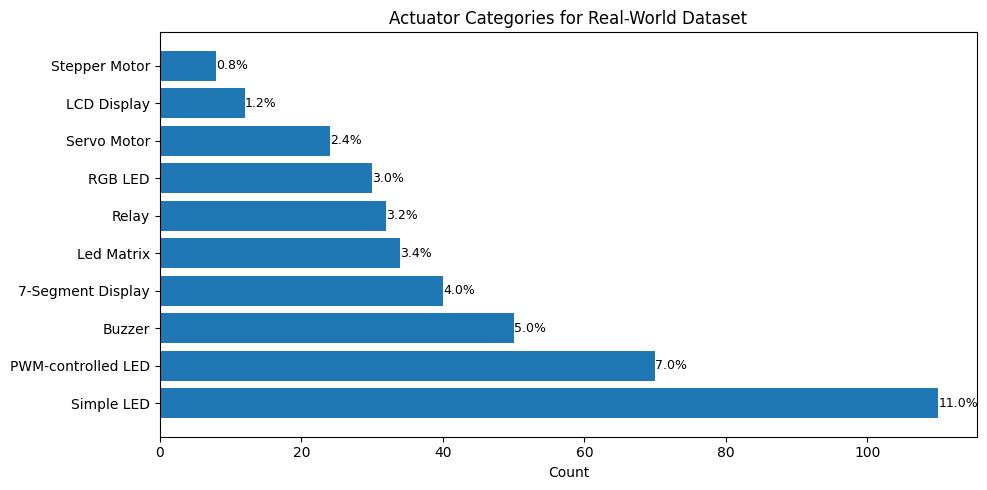

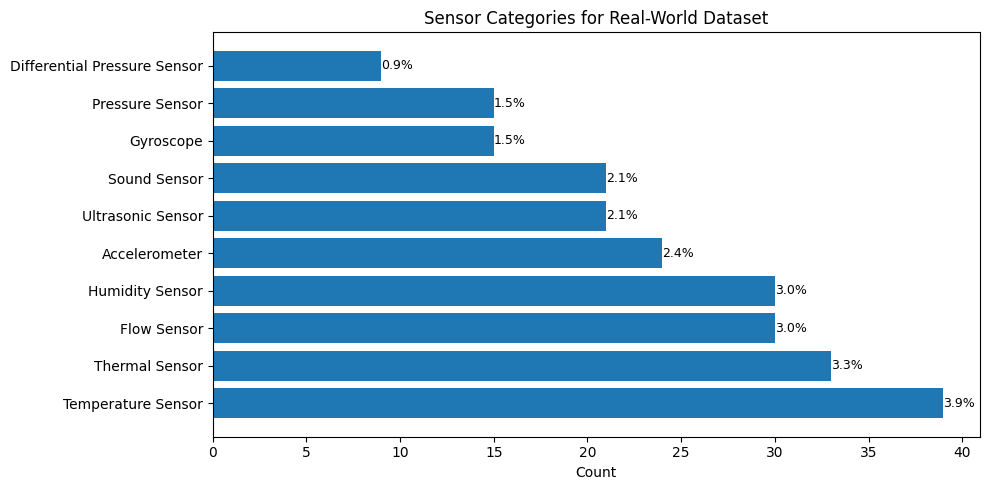

In [3]:
## Real World Data Plots

import json
import matplotlib.pyplot as plt

# Load JSON from a file
with open("real_world_stats.json", "r") as file:
    data = json.load(file)

# Extract categorized tag distributions
categorized_tags = data.get("categorized_tag_distribution", {})

# Helper to get top N tags from a category
def get_top_tags(category_name, top_n=10):
    tags = categorized_tags.get(category_name, {}).get("tags", {})
    sorted_tags = sorted(tags.items(), key=lambda x: x[1]["count"], reverse=True)
    return sorted_tags[:top_n], len(tags)

# Get top tags for each category
top_actuators, total_actuators = get_top_tags("Actuators")
top_sensors, total_sensors = get_top_tags("Sensors")
top_libraries, total_libraries = get_top_tags("Libraries/Frameworks")
top_misc, total_misc = get_top_tags("Hardware/Context/Other")
_, total_comm_protocols = get_top_tags("Communication")

# Apply count modifications only to top N displayed items
for tag, details in top_actuators:
    details["count"] *= 2
for tag, details in top_sensors:
    details["count"] *= 3

# Function to pretty print
def print_top(title, items):
    print(f"\nTop {len(items)} {title}")
    print("-" * (12 + len(title)))
    for tag, details in items:
        print(f"{tag:25} | Count: {details['count']}")

# Print results
print_top("Actuators", top_actuators)
print_top("Sensors", top_sensors)
print_top("Libraries", top_libraries)
print_top("Miscellaneous/Hardware", top_misc)

# Total distinct tags
print("\n--- Total Unique Entries ---")
print(f"Total Distinct Actuators:           {total_actuators}")
print(f"Total Distinct Sensors:             {total_sensors}")
print(f"Total Distinct Libraries:           {total_libraries}")
print(f"Total Distinct Communication Protocols: {total_comm_protocols}")

# Optional plotting
def plot_top(tags, title, filename, total_count):
    labels = [x[0] for x in tags]
    counts = [x[1]['count'] for x in tags]
    percentages = [f"{(count / total_count) * 100:.1f}%" for count in counts]

    plt.figure(figsize=(10, 5))
    bars = plt.barh(labels, counts)
    plt.title(f"{title} Categories for Real-World Dataset")
    plt.xlabel("Count")

    # Add percentage text to the right of each bar
    for bar, percentage in zip(bars, percentages):
        width = bar.get_width()
        plt.text(width , bar.get_y() + bar.get_height() / 2, percentage,
                 va='center', ha='left', fontsize=9)

    plt.tight_layout()
    plt.savefig(filename, dpi=300)
    plt.show()

plot_top(top_actuators, "Actuator", "Results_Fig2_top_10_actuators.png", total_count=1000)
plot_top(top_sensors, "Sensor", "Results_Fig1_top_10_sensors.png", total_count=1000)


### Synthetic Data Plots ###

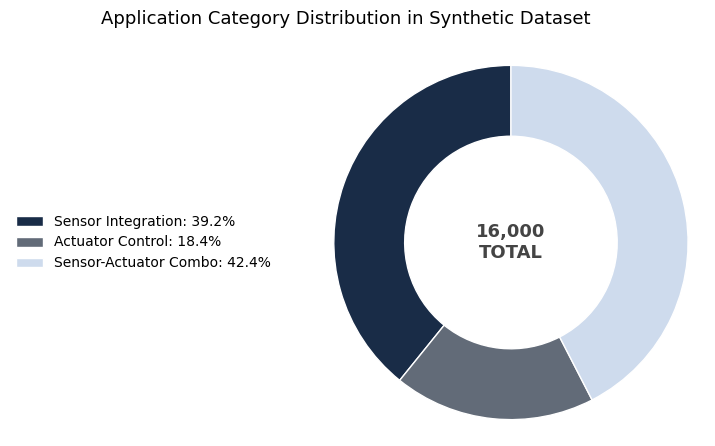

In [22]:
import matplotlib.pyplot as plt

# Data
labels = ['Sensor Integration', 'Actuator Control', 'Sensor-Actuator Combo']
sizes = [6271, 2941, 6788]
# Colors: soft pastel (orange, pink, green)
colors = ["#192c47", "#626b78", "#cedbed"]
total = sum(sizes)
percentages = [f"{label}: {value/total*100:.1f}%" for label, value in zip(labels, sizes)]

# Create figure with tighter layout
fig, (ax_legend, ax_chart) = plt.subplots(
    ncols=2, figsize=(7.5, 4.5), gridspec_kw={"width_ratios": [1, 1.5]}
)

# Pie chart (donut style)
wedges, _ = ax_chart.pie(
    sizes,
    colors=colors,
    startangle=90,
    wedgeprops=dict(width=0.4, edgecolor="white")
)
ax_chart.text(0, 0, f"{total:,}\nTOTAL", ha="center", va="center", fontsize=13, weight="bold", color="#444")
ax_chart.axis("equal")

# Legend on left
ax_legend.legend(wedges, percentages, loc="center", frameon=False, fontsize=10)
ax_legend.axis("off")  # No visuals on legend subplot

# Title
fig.suptitle("Application Category Distribution in Synthetic Dataset", fontsize=13)

# Save and show
plt.tight_layout()
plt.savefig("Fig3_donut_final_clean.png", dpi=300)
plt.show()


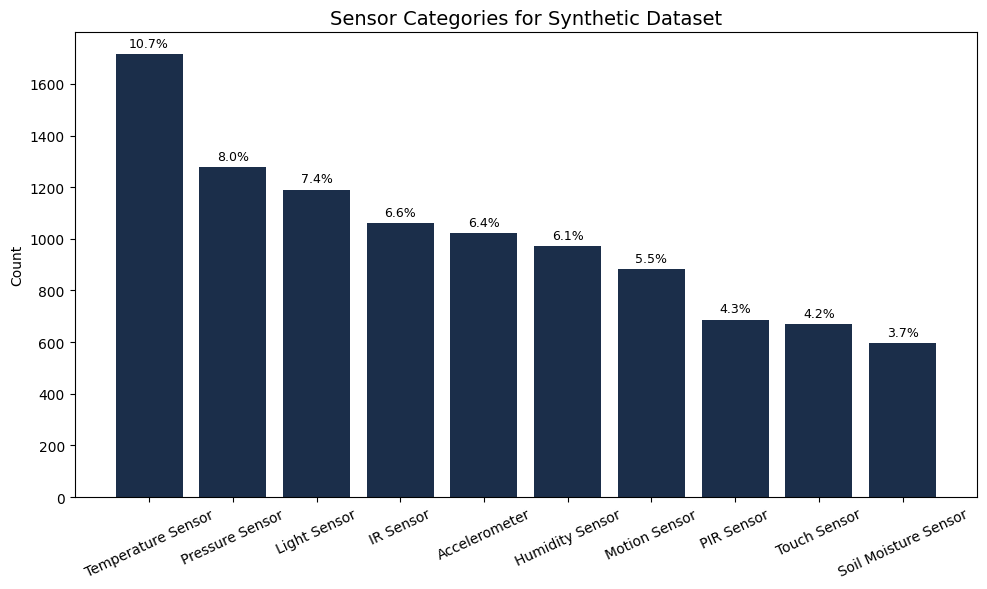

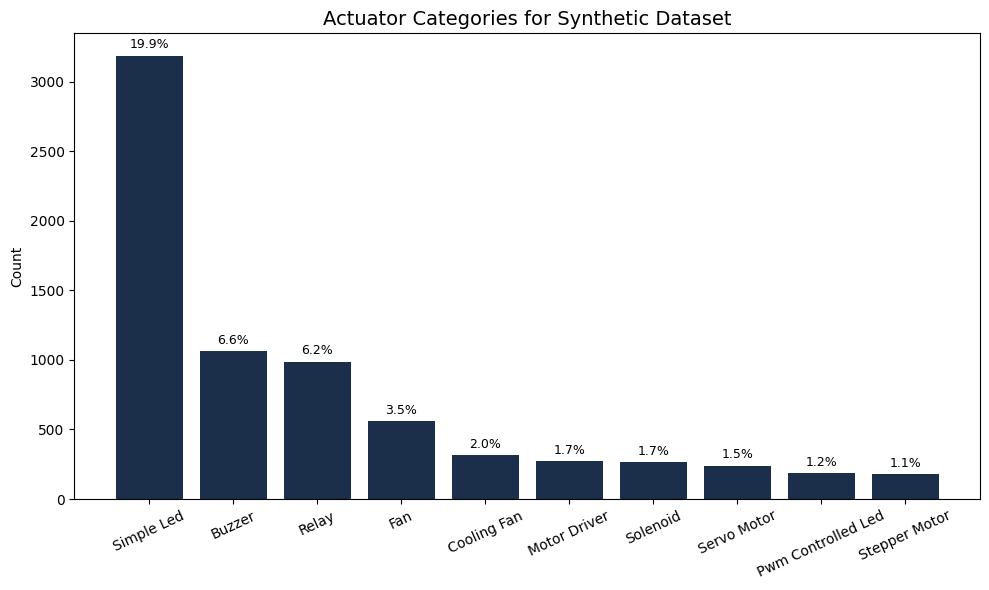

In [4]:
import json
import matplotlib.pyplot as plt

# Load JSON data
with open("synthetic_stats.json", "r") as file:
    data = json.load(file)

# Helper to convert labels to Title Case (except PIR and IR)
def custom_title_case(name):
    name = name.title()
    name = name.replace("Pir", "PIR").replace("Ir", "IR")
    return name

def title_case_top_n(d, n=10):
    sorted_items = sorted(d.items(), key=lambda x: x[1], reverse=True)[:n]
    return {custom_title_case(k): v for k, v in sorted_items}

# Extract and clean top 10 sensor and actuator data
sensors_raw = data["category_matches"]["sensor_reading"]
actuators_raw = data["category_matches"]["actuators"]
sensors = title_case_top_n(sensors_raw, 10)
actuators = title_case_top_n(actuators_raw, 10)

def plot_bar_vertical(data_dict, title, filename, total_count):
    labels = list(data_dict.keys())
    counts = list(data_dict.values())
    percentages = [(count / total_count) * 100 for count in counts]

    plt.figure(figsize=(10, 6))
    bars = plt.bar(labels, counts, color="#1b2e4a")
    plt.title(title, fontsize=14)
    plt.ylabel("Count")

    # Add percentage labels on top of each bar
    for bar, percentage in zip(bars, percentages):
        yval = bar.get_height()
        plt.text(bar.get_x() + bar.get_width()/2, yval + max(counts)*0.01,
                 f"{percentage:.1f}%", ha='center', va='bottom', fontsize=9)

    plt.xticks(rotation=25)
    plt.tight_layout()
    plt.savefig(filename, dpi=300)
    plt.show()

plot_bar_vertical(sensors, "Sensor Categories for Synthetic Dataset", "top10_sensors_vertical.png", total_count=16000)
plot_bar_vertical(actuators, "Actuator Categories for Synthetic Dataset", "top10_actuators_vertical.png", total_count=16000)


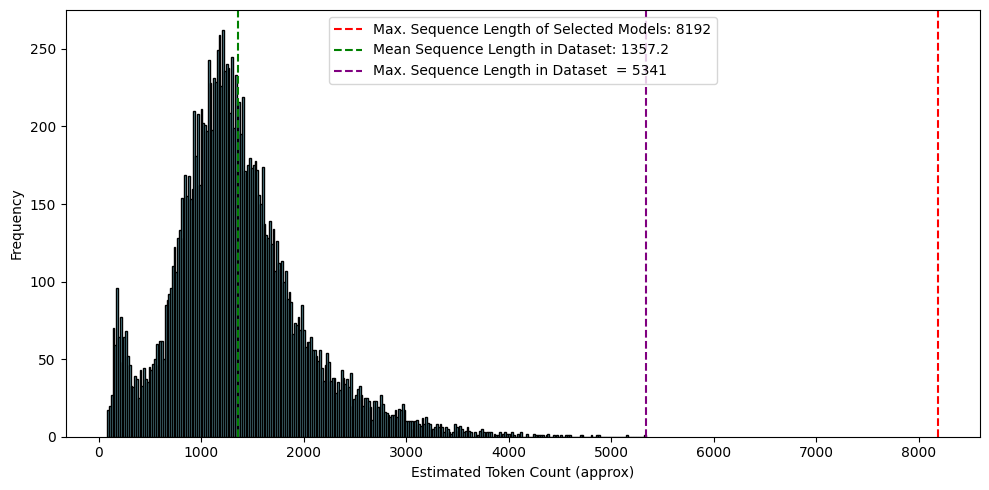

📏 Average example length: 1357.24 tokens
🔺 Maximum example length: 5341 tokens
⚠️  Examples longer than 8192 tokens: 0 out of 16000


In [37]:
# Analyze dataset examples length
from datasets import load_dataset
import numpy as np
import matplotlib.pyplot as plt

MAX_SEQ_LENGTH = 8192

def estimate_tokens(text):
    """Rough estimation of tokens (approx 4 characters per token)"""
    if not text:
        return 0
    return len(text) // 4

# Load dataset
train_dataset = load_dataset("json", data_files="Qwen_Training_Set1_16K_JSONL_Dataset.jsonl", split="train") 

# Format prompt+completion into one field
def format_completion_example(example):
    prompt = example.get("prompt", "")
    completion = example.get("completion", "")
    return {"text": f"{prompt}{completion}"}

train_dataset = train_dataset.map(format_completion_example, batched=False)

# Estimate token lengths
token_counts = [estimate_tokens(example['text']) for example in train_dataset]
avg_length = np.mean(token_counts)
max_length = np.max(token_counts)
over_limit = sum(c > MAX_SEQ_LENGTH for c in token_counts)

# Plot token length distribution
plt.figure(figsize=(10, 5))
plt.hist(token_counts, bins=300, color="#63a1ad", edgecolor='black')  # Light blue hex

# Mark max, mean, and limit lines
plt.axvline(x=MAX_SEQ_LENGTH, color='red', linestyle='--', label=f'Max. Sequence Length of Selected Models: {MAX_SEQ_LENGTH}')
plt.axvline(x=avg_length, color='green', linestyle='--', label=f'Mean Sequence Length in Dataset: {avg_length:.1f}')
plt.axvline(x=max_length, color='purple', linestyle='--', label=f'Max. Sequence Length in Dataset  = {max_length}')

# Labels and styling
#plt.title('Token Length Distribution in Training Dataset')
plt.xlabel('Estimated Token Count (approx)')
plt.ylabel('Frequency')
plt.legend()
plt.tight_layout()
# Save image at 300 DPI
plt.savefig("Fig5.png", dpi=300)
plt.show()

# Print stats
print(f"📏 Average example length: {avg_length:.2f} tokens")
print(f"🔺 Maximum example length: {max_length} tokens")
print(f"⚠️  Examples longer than {MAX_SEQ_LENGTH} tokens: {over_limit} out of {len(train_dataset)}")


c:\Users\Admin\AppData\Local\Programs\Python\Python312\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


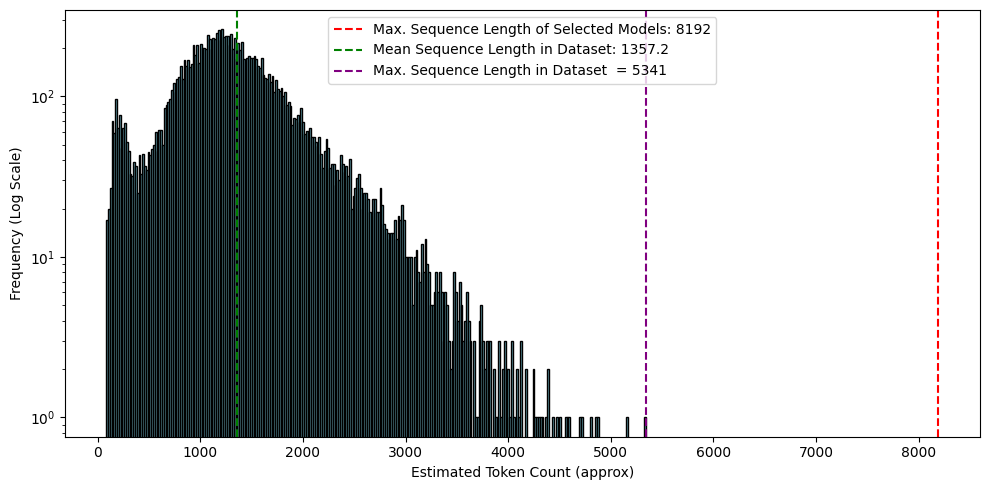

📏 Average example length: 1357.24 tokens
🔺 Maximum example length: 5341 tokens
⚠️  Examples longer than 8192 tokens: 0 out of 16000


In [1]:
from datasets import load_dataset
import numpy as np
import matplotlib.pyplot as plt

MAX_SEQ_LENGTH = 8192

def estimate_tokens(text):
    """Rough estimation of tokens (approx 4 characters per token)"""
    if not text:
        return 0
    return len(text) // 4

# Load dataset
train_dataset = load_dataset("json", data_files="Qwen_Training_Set1_16K_JSONL_Dataset.jsonl", split="train") 

# Format prompt+completion into one field
def format_completion_example(example):
    prompt = example.get("prompt", "")
    completion = example.get("completion", "")
    return {"text": f"{prompt}{completion}"}

train_dataset = train_dataset.map(format_completion_example, batched=False)

# Estimate token lengths
token_counts = [estimate_tokens(example['text']) for example in train_dataset]
avg_length = np.mean(token_counts)
max_length = np.max(token_counts)
over_limit = sum(c > MAX_SEQ_LENGTH for c in token_counts)

# Plot token length distribution
plt.figure(figsize=(10, 5))
plt.hist(token_counts, bins=300, color="#63a1ad", edgecolor='black')  # Light blue hex

# Mark max, mean, and limit lines
plt.axvline(x=MAX_SEQ_LENGTH, color='red', linestyle='--', label=f'Max. Sequence Length of Selected Models: {MAX_SEQ_LENGTH}')
plt.axvline(x=avg_length, color='green', linestyle='--', label=f'Mean Sequence Length in Dataset: {avg_length:.1f}')
plt.axvline(x=max_length, color='purple', linestyle='--', label=f'Max. Sequence Length in Dataset  = {max_length}')

# Set y-axis to logarithmic scale
plt.yscale('log')

# Labels and styling
plt.xlabel('Estimated Token Count (approx)')
plt.ylabel('Frequency (Log Scale)')
plt.legend()
plt.tight_layout()

# Save image at 300 DPI
plt.savefig("Fig5.png", dpi=300)
plt.show()

# Print stats
print(f"📏 Average example length: {avg_length:.2f} tokens")
print(f"🔺 Maximum example length: {max_length} tokens")
print(f"⚠️  Examples longer than {MAX_SEQ_LENGTH} tokens: {over_limit} out of {len(train_dataset)}")